# Ejercicio de Clases: Análisis de Modelos de Regresión Lineal

---

En este ejercicio analizaremos el dataset **Palmer Penguins**, con mediciones morfológicas de pingüinos de la Antártica. El objetivo es construir y validar modelos de regresión lineal —simple y múltiple— para predecir la **masa corporal** (`body_mass_g`) a partir de características físicas.

| Variable | Descripción | Rol |
|---|---|---|
| `flipper_length_mm` | Largo de la aleta (mm) | Predictor (Ej. 1) |
| `bill_length_mm` | Largo del pico (mm) | Predictor (Ej. 2) |
| `bill_depth_mm` | Profundidad del pico (mm) | Predictor (Ej. 2) |
| `body_mass_g` | Masa corporal (g) | **Variable respuesta** |


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression


In [2]:
df = sns.load_dataset('penguins').dropna().reset_index(drop=True)
print(f'Dataset: {df.shape[0]} observaciones, {df.shape[1]} variables')
df[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g']].describe()


Dataset: 333 observaciones, 7 variables


,flipper_length_mm,bill_length_mm,bill_depth_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,200.966967,43.992793,17.164865,4207.057057
std,14.015765,5.468668,1.969235,805.215802
min,172.000000,32.100000,13.100000,2700.000000
25%,190.000000,39.500000,15.600000,3550.000000
50%,197.000000,44.500000,17.300000,4050.000000
75%,213.000000,48.600000,18.700000,4775.000000
max,231.000000,59.600000,21.500000,6300.000000


---
# Ejercicio 1: Regresión Lineal Simple

Modelaremos la masa corporal (`body_mass_g`) en función del **largo de la aleta** (`flipper_length_mm`).


## 1a) Análisis Exploratorio de Datos

> Grafique las distribuciones de `flipper_length_mm` y `body_mass_g` (histogramas con p-value de Shapiro-Wilk) y el diagrama de dispersión entre ambas.
> ¿Las variables presentan distribución normal? ¿Existe relación lineal aparente?

*Recordar: los supuestos de normalidad en regresión lineal aplican a los **residuos**, no a las variables predictoras.*


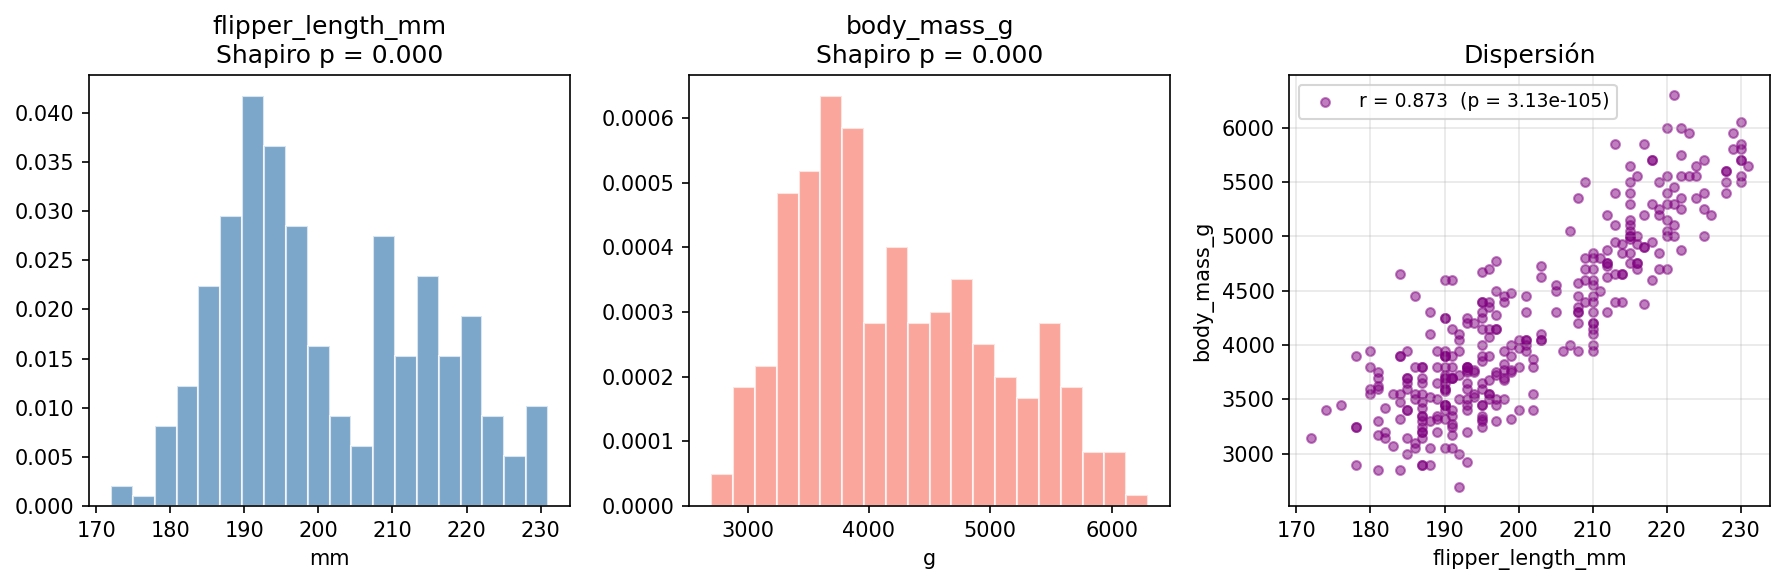

In [ ]:
x = df['flipper_length_mm']
y = df['body_mass_g']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=150)

# Histograma x
shap_x = stats.shapiro(x)[1]
axes[0].hist(x, bins=20, color='steelblue', alpha=0.7, density=True, edgecolor='white')
axes[0].set_title(f'flipper_length_mm\nShapiro p = {shap_x:.3f}')
axes[0].set_xlabel('mm')

# Histograma y
shap_y = stats.shapiro(y)[1]
axes[1].hist(y, bins=20, color='salmon', alpha=0.7, density=True, edgecolor='white')
axes[1].set_title(f'body_mass_g\nShapiro p = {shap_y:.3f}')
axes[1].set_xlabel('g')

# Dispersión
# el grafico de dispersion permite determinar la relación entre las variables
r, pval = stats.pearsonr(x, y)
axes[2].scatter(x, y, alpha=0.5, color='purple', s=18,
                label=f'r = {r:.3f}  (p = {pval:.2e})')
axes[2].set_xlabel('flipper_length_mm')
axes[2].set_ylabel('body_mass_g')
axes[2].legend(loc='upper left', fontsize=9)
axes[2].set_title('Dispersión')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 1b) Estimación de Coeficientes

> Calcule manualmente $\hat{\beta}_0$ y $\hat{\beta}_1$. Grafique los datos junto con la recta ajustada e incluya el coeficiente de Pearson.

$$\hat{\beta}_1 = \frac{S_{xy}}{S_{xx}}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\,\bar{x}$$

$$S_{xx} = \sum_{i=1}^n (x_i - \bar{x})^2, \qquad S_{xy} = \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$


beta0 = -5872.0927
beta1 = 50.1533
Modelo: body_mass_g = -5872.09 + 50.15 * flipper_length_mm


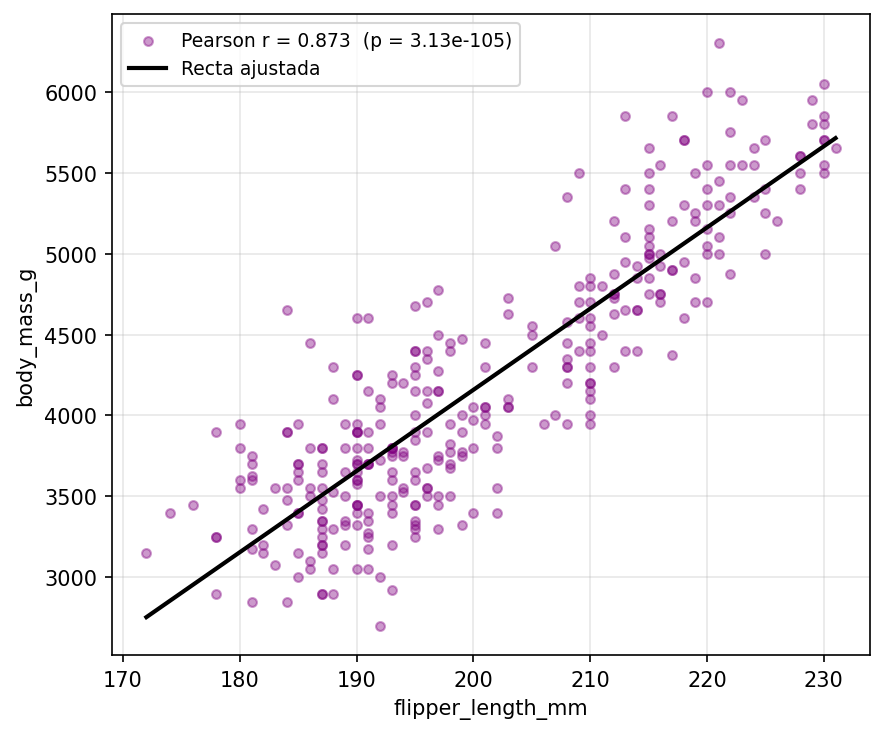

In [ ]:
n = len(x) # tamano de la muestra
S_xx = np.sum((x - x.mean()) ** 2) # S_xx es la suma de los cuadrados de las diferencias entre cada valor de x y la media de x
S_xy = np.sum((x - x.mean()) * (y - y.mean())) # S_xy es la suma de los productos de las diferencias entre cada valor de x y la media de x, y cada valor de y y la media de y

beta1 = S_xy / S_xx # coeficiente de la pendiente (beta1) se calcula dividiendo S_xy por S_xx
beta0 = y.mean() - beta1 * x.mean() # coeficiente de la intersección (beta0) se calcula restando el producto de beta1 y la media de x a la media de y

print(f"beta0 = {beta0:.4f}")
print(f"beta1 = {beta1:.4f}")
print(f"Modelo: body_mass_g = {beta0:.2f} + {beta1:.2f} * flipper_length_mm")

r, pval = stats.pearsonr(x, y) # correlacion de pearnon
# numeros para la grafica de la regresion
x_line = np.linspace(x.min(), x.max(), 300)

## graficamos el ajuste
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.scatter(
    x,
    y,
    alpha=0.4,
    color="purple",
    s=18,
    label=f"Pearson r = {r:.3f}  (p = {pval:.2e})",
    zorder=3,
)
ax.plot(
    x_line,
    beta0 + beta1 * x_line,
    color="black",
    lw=2,
    label="Recta ajustada",
    zorder=4,
)
ax.set_xlabel("flipper_length_mm")
ax.set_ylabel("body_mass_g")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1c) Coeficiente de Determinación $R^2$

> Calcule $R^2$. ¿Qué proporción de la varianza de la masa corporal explica el largo de la aleta?

$$SS_T = \sum(y_i - \bar{y})^2, \quad SS_E = SS_T - \hat{\beta}_1 S_{xy}, \quad R^2 = 1 - \frac{SS_E}{SS_T}$$


In [21]:
SS_T = np.sum((y - y.mean()) ** 2)
SS_E = SS_T - beta1 * S_xy
SS_R = SS_T - SS_E
R2 = 1 - SS_E / SS_T

print(f"SS_T = {SS_T:,.2f}")
print(f"SS_R = {SS_R:,.2f}")
print(f"SS_E = {SS_E:,.2f}")
print(f"R2 = {R2:.4f}: el modelo explica el {R2*100:.1f}% de la varianza total")

SS_T = 215,259,665.92
SS_R = 164,047,703.19
SS_E = 51,211,962.73
R2 = 0.7621: el modelo explica el 76.2% de la varianza total


> Notemos que el coeficiente de terminación se computa como:
> $$R^2 = 1 - \frac{SS_E}{SS_T}$$
> Donde podemos entender el $SS_E$ como la varianza por el error. Así, si la varianza que es explicada por el error es 0, entonces $R^2=1$, por lo cuál modelo explica el 100% de la varinza. Lo mismo ocurrene en caso contrario.


## 1d) Test-$t$ sobre los Coeficientes

> Plantee las hipótesis y calcule los estadísticos $t$ bilaterales para $\beta_0$ y $\beta_1$. Interprete.

Los test-t sobre los estadísticos $\beta_0$ y $\beta_1$ nos permiten estimar de forma robusta si existen soporte necesario para los diferentes coeficientes. Es decir, si la información que estos entregan es confiable. Para esto se tienen los siguientes tests:

$$H_0: \beta_j = 0 \quad \text{vs} \quad H_a: \beta_j \neq 0$$

$$T_{\beta_0} = \frac{\hat{\beta}_0}{\sqrt{\hat{\sigma}^2\!\left(\frac{1}{n} + \frac{\bar{x}^2}{S_{xx}}\right)}}, \qquad T_{\beta_1} = \frac{\hat{\beta}_1}{\sqrt{\hat{\sigma}^2 / S_{xx}}}$$

con $\hat{\sigma}^2 = SS_E\,/\,(n-2)$ y distribución $t_{n-2}$ bajo $H_0$.


In [23]:
sigma2 = SS_E / (n - 2)  # varianza estimada del error

T_b0 = beta0 / np.sqrt(sigma2 * (1 / n + x.mean() ** 2 / S_xx))
T_b1 = beta1 / np.sqrt(sigma2 / S_xx)

p_b0 = 2 * stats.t.sf(np.abs(T_b0), df=n - 2)
p_b1 = 2 * stats.t.sf(np.abs(T_b1), df=n - 2)

print(f"T_b0 = {T_b0:.3f}, p_b0 = {p_b0:.3e}")
print(f"T_b1 = {T_b1:.3f}, p_b1 = {p_b1:.3e}")

T_b0 = -18.925, p_b0 = 1.184e-54
T_b1 = 32.562, p_b1 = 3.133e-105


## 1e) ANOVA de la Regresión

> Aplique ANOVA para evaluar si el modelo en su conjunto es significativo. Compare $F_0$ con $T_{\beta_1}^2$.

$$H_0: \beta_1 = 0 \quad \text{vs} \quad H_a: \beta_1 \neq 0$$

$$F_0 = \frac{MS_R}{MS_E} = \frac{SS_R\,/\,1}{SS_E\,/\,(n-2)} \sim F_{1,\,n-2} \text{ bajo } H_0$$


In [24]:
MS_R = SS_R / 1
MS_E = SS_E / (n - 2)
F0 = MS_R / MS_E
p_F = stats.f.sf(F0, 1, n - 2)

print(f"MS_R = {MS_R:,.2f}")
print(f"MS_E = {MS_E:,.2f}")
print(f"F0 = {F0:.4f}")
print(f"p = {p_F:.4e}")
print(f"Verificacion: T_b1^2 = {T_b1**2:.4f}  vs  F0 = {F0:.4f}  (deben coincidir)")

MS_R = 164,047,703.19
MS_E = 154,718.92
F0 = 1060.2950
p = 3.1328e-105
Verificacion: T_b1^2 = 1060.2950  vs  F0 = 1060.2950  (deben coincidir)


## 1f) Intervalos de Confianza

> Calcule y grafique los IC del 95% para (i) la **respuesta media** $\mu_{Y|x_0}$ y (ii) una **nueva observación** $Y_0$.

**IC para la media:**
$$\hat{\mu}_{Y|x_0} \pm t_{\alpha/2,\,n-2}\,\sqrt{\hat{\sigma}^2\!\left[\frac{1}{n}+\frac{(x_0-\bar{x})^2}{S_{xx}}\right]}$$

**IC de predicción** (banda más ancha — incluye variabilidad del error individual):
$$\hat{y}_0 \pm t_{\alpha/2,\,n-2}\,\sqrt{\hat{\sigma}^2\!\left[1+\frac{1}{n}+\frac{(x_0-\bar{x})^2}{S_{xx}}\right]}$$


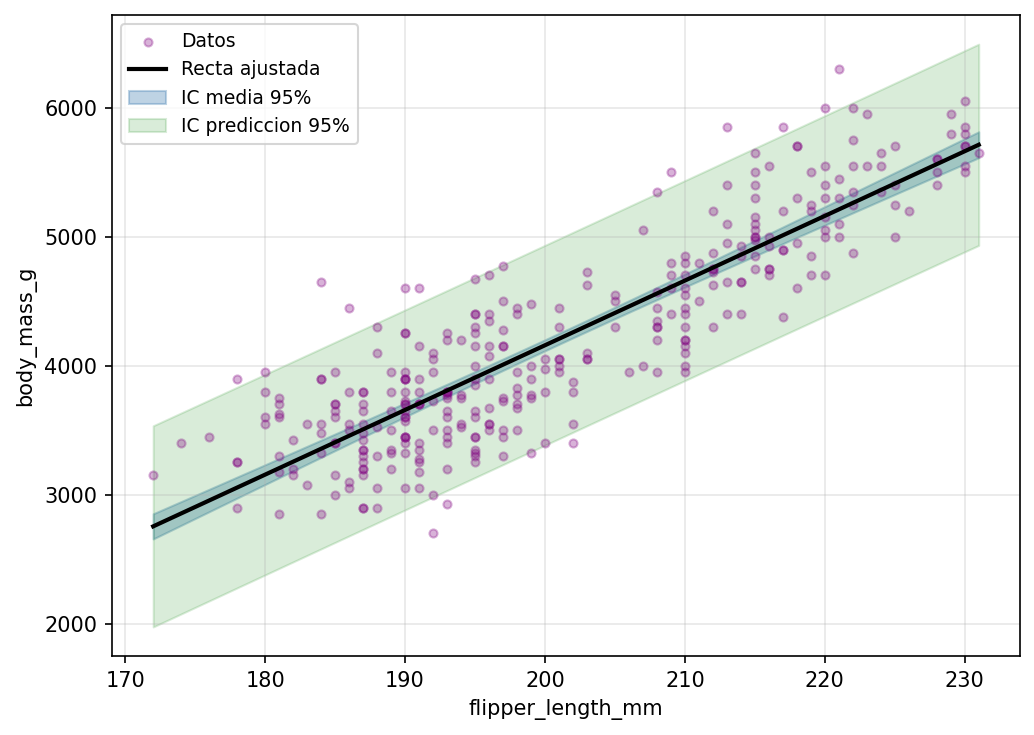

In [8]:
alpha = 0.05
x0 = np.linspace(x.min(), x.max(), 300)
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 2)
y_hat = beta0 + beta1 * x0

# IC para la media
se_mean = np.sqrt(sigma2 * (1 / n + (x0 - x.mean()) ** 2 / S_xx))
CI_lo, CI_hi = y_hat - t_crit * se_mean, y_hat + t_crit * se_mean

# IC de prediccion
se_pred = np.sqrt(sigma2 * (1 + 1 / n + (x0 - x.mean()) ** 2 / S_xx))
PI_lo, PI_hi = y_hat - t_crit * se_pred, y_hat + t_crit * se_pred

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ax.scatter(x, y, alpha=0.3, color="purple", s=15, zorder=3, label="Datos")
ax.plot(x0, y_hat, color="black", lw=2, label="Recta ajustada", zorder=4)
ax.fill_between(x0, CI_lo, CI_hi, alpha=0.35, color="steelblue", label="IC media 95%")
ax.fill_between(x0, PI_lo, PI_hi, alpha=0.15, color="green", label="IC prediccion 95%")
ax.set_xlabel("flipper_length_mm")
ax.set_ylabel("body_mass_g")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1g) Verificación con OLS y Análisis de Residuos

> Use `statsmodels.OLS` para obtener el reporte completo. Compare con los cálculos manuales.
> Analice la distribución de los residuos: ¿son aproximadamente normales? ¿Hay algún patrón sistemático?


In [9]:
modelo_ols = sm.OLS(y, sm.add_constant(x)).fit()
print(modelo_ols.summary())


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Sat, 02 May 2026   Prob (F-statistic):          3.13e-105
Time:                        23:05:26   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5872.0927    310.28

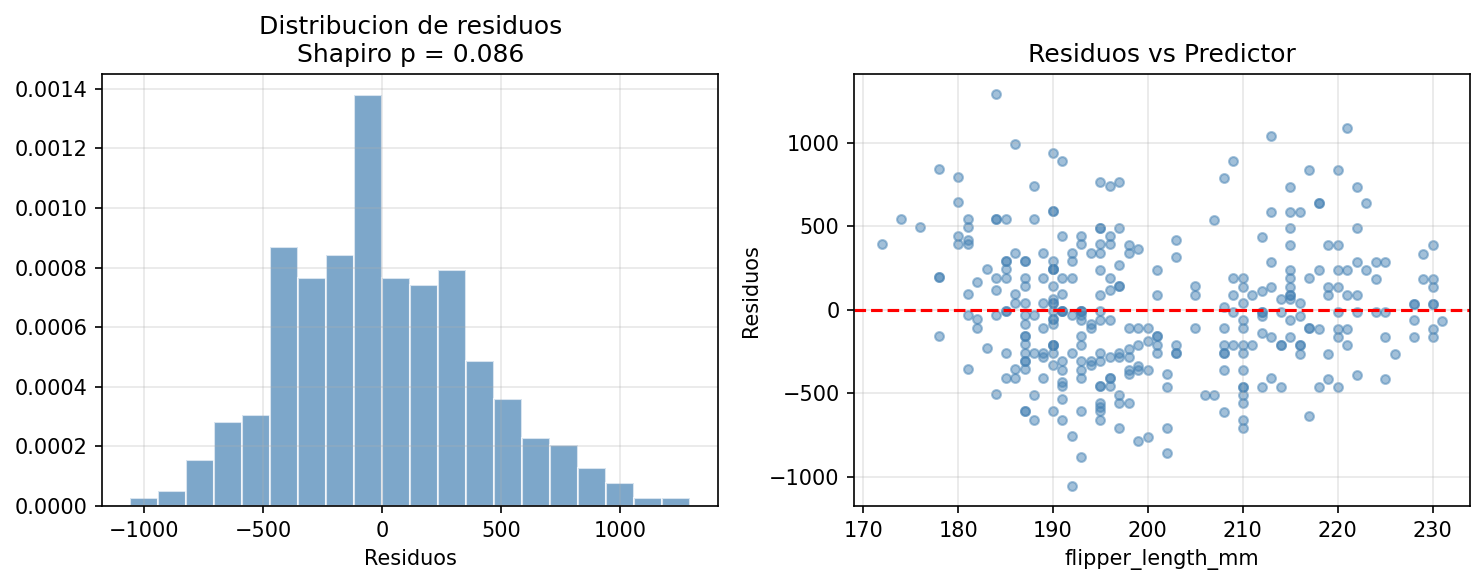

Pregunta: puede explicar el patron observado en los residuos?


In [10]:
resid     = modelo_ols.resid
shapiro_p = stats.shapiro(resid)[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

axes[0].hist(resid, bins=20, color='steelblue', alpha=0.7, density=True, edgecolor='white')
axes[0].set_title(f'Distribucion de residuos\nShapiro p = {shapiro_p:.3f}')
axes[0].set_xlabel('Residuos')
axes[0].grid(alpha=0.3)

axes[1].scatter(x, resid, alpha=0.5, color='steelblue', s=18)
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('flipper_length_mm')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos vs Predictor')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Pregunta: puede explicar el patron observado en los residuos?')


---
# Ejercicio 2: Regresión Lineal Múltiple

Extendemos el modelo para predecir `body_mass_g` con **tres predictores simultáneos**:
`bill_length_mm`, `bill_depth_mm` y `flipper_length_mm`.


## 2a) EDA Bivariado — Relación con cada Predictor

> Grafique `body_mass_g` vs cada predictor con el coeficiente de Pearson y su valor-$p$.
> ¿Qué relaciones anticipan al incluirse en un modelo múltiple?


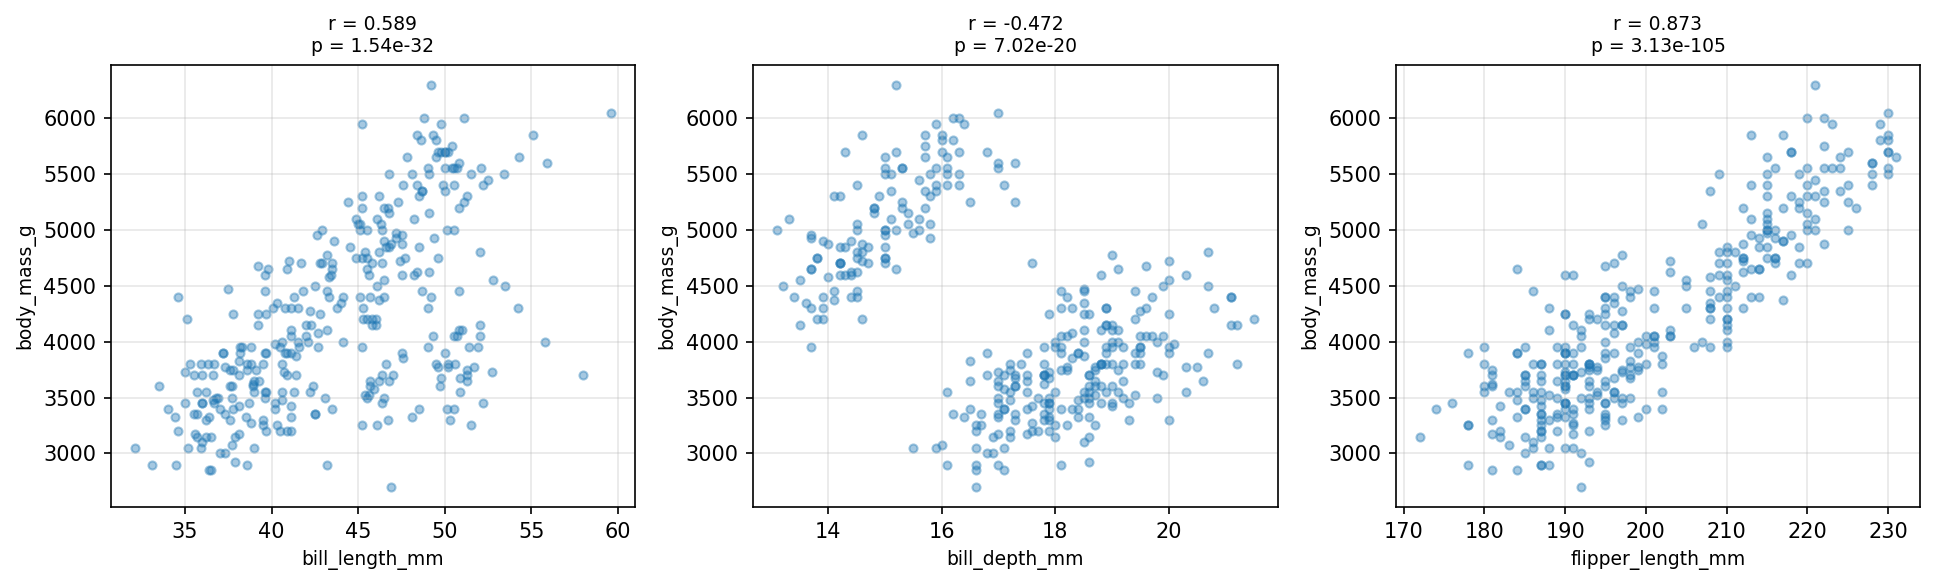

In [25]:
predictors = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
y_multi = df["body_mass_g"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=150)
for ax, col in zip(axes, predictors):
    xi = df[col]
    ri, pi = stats.pearsonr(xi, y_multi)
    ax.scatter(xi, y_multi, alpha=0.4, s=15)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("body_mass_g", fontsize=9)
    ax.set_title(f"r = {ri:.3f}\np = {pi:.2e}", fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2b) Matriz de Diseño y Ecuaciones Normales

> Construya la **matriz de diseño** $\mathbf{X}$ (con columna de unos) y estime $\hat{\boldsymbol{\beta}}$ resolviendo las ecuaciones normales.


Los modelos de regresión lineal multivariada poseen la siguiente forma para estimar los parámetros que describen la relación entre variables.

El modelo múltiple es:
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \qquad
\mathbf{X} = \begin{bmatrix} \mathbf{1} & \mathbf{x}_1 & \mathbf{x}_2 & \mathbf{x}_3 \end{bmatrix}_{n \times 4}$$

Minimizando $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

Donde $\hat{\boldsymbol{\beta}} = [\hat{\beta_0},\hat{\beta_1}, ..., \hat{\beta_n}]$ (en este caso 3). Notar que es importante definir $\mathbf{X}$ con la primera columna de 1, sino el cálculo falla. 

Este modelo nos permitirá poder estimar la realción lineal entre variables.

In [35]:
y_arr = df["body_mass_g"].values
X_df = df[predictors].copy()
X_sm = sm.add_constant(X_df)  # agrega columna 'const' de unos
X_arr = X_sm.values

# Paso 1: X^T X # poner X.T es equivalente a X transpuesta
XtX = X_arr.T @ X_arr # <- El @ correspode al producto matricial. 
                      #    Corresponde a X^T X, si se hace * es producto elemento a elemento
# Paso 2: (X^T X)^{-1}
XtX_inv = np.linalg.inv(XtX) # np.linalg.inv() calcula la inversa de una matriz
# Paso 3: X^T y
Xty = X_arr.T @ y_arr
# Paso 4: beta = (X^T X)^{-1} X^T y
beta_hat = XtX_inv @ Xty # notemos que cada e ntrada corresponde a un coeficiente del modelo
print(beta_hat) # <- los coeficientes
print(f"Dimension de X: {X_arr.shape}")
print()
print("Coeficientes estimados:")
for name, b in zip(X_sm.columns, beta_hat):
    print(f"{name:22} {b:10.4f}")

[-6.44547604e+03  3.29286254e+00  1.78363910e+01  5.07621317e+01]
Dimension de X: (333, 4)

Coeficientes estimados:
const                  -6445.4760
bill_length_mm             3.2929
bill_depth_mm             17.8364
flipper_length_mm         50.7621


## 2c) ANOVA de la Regresión Múltiple

> Aplique ANOVA con $m = 3$ predictores. ¿Existe al menos un predictor significativo?

El test anova, para una regresión lineal simple y una regresión lineal múltiple tienen el mismo significado. Es decir, evaluan si existe alguna relación lineal entre las variables independientes y la variable dependiente.

$$H_0: \beta_1 = \beta_2 = \beta_3 = 0 \quad \text{vs} \quad H_a: \exists\, \beta_j \neq 0$$

$$SS_T = \mathbf{y}^T\mathbf{y} - \frac{\left(\sum y_i\right)^2}{n}, \quad
SS_R = \hat{\boldsymbol{\beta}}^T\mathbf{X}^T\mathbf{y} - \frac{\left(\sum y_i\right)^2}{n} \quad SS_E = SS_T - SS_R$$

$$F_0 = \frac{SS_R/m}{SS_E/(n-m-1)} \sim F_{m,\,n-m-1} \text{ bajo } H_0$$


In [34]:
n_obs = len(y_arr)
m = len(predictors)

SS_T_m = y_arr @ y_arr - np.sum(y_arr) ** 2 / n_obs
SS_R_m = beta_hat @ X_arr.T @ y_arr - np.sum(y_arr) ** 2 / n_obs
SS_E_m = SS_T_m - SS_R_m

MS_R_m = SS_R_m / m # promedio de cuadrados del modelo
MS_E_m = SS_E_m / (n_obs - m - 1) # promedio de cuadrados del error
F0_m = MS_R_m / MS_E_m # Estimador F0 anova
p_F_m = stats.f.sf(F0_m, m, n_obs - m - 1) # p-valor del test F

print(f"n = {n_obs},  m = {m}")
print('--------')
print(f"SS_T = {SS_T_m:>15,.2f}")
print(f"SS_R = {SS_R_m:>15,.2f}")
print(f"SS_E = {SS_E_m:>15,.2f}")
print('--------')
print(f"F0 = {F0_m:.4f}")
print(f"p = {p_F_m:.4e}")

n = 333,  m = 3
--------
SS_T =  215,259,665.92
SS_R =  164,444,754.11
SS_E =   50,814,911.80
--------
F0 = 354.8980
p = 9.2608e-103


## 2d) Test-$t$ de Significancia Individual

> Evalúe la significancia de cada coeficiente. ¿Cuáles son significativos con $\alpha = 0.05$?

El test-t, a diferencia que para una regresión lineal simple, ahora se diferencia del test ANOVA. En este caso, el test-t evalua de forma individual, por lo cuál permite entender cuál de todas las variables explicativas se relaciona con la variable de interés. Este test se computa de la siguiente forma:


$$T_j = \frac{\hat{\beta}_j}{se(\hat{\beta}_j)}, \quad se(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2\,\mathbf{C}_{jj}}, \quad \mathbf{C} = (\mathbf{X}^T\mathbf{X})^{-1}$$

con $\hat{\sigma}^2 = SS_E\,/\,(n-m-1)$ y distribución $t_{n-m-1}$ bajo $H_0$.


In [36]:
sigma2_m = SS_E_m / (n_obs - m - 1) # <- varianza estimada del error del modelo
C = XtX_inv # <- Viene de antes y es la matriz de varianzas y covarianzas de los estimadores beta
se_betas = np.sqrt(sigma2_m * np.diag(C)) # <- calculamos de forma directa el error estandar de cada beta

T_betas = beta_hat / se_betas # <- el estadistico t de cada beta se calcula dividiendo cada beta por su error estandar
p_betas = 2 * stats.t.sf(np.abs(T_betas), df=n_obs - m - 1) # <- el p-valor de cada beta se calcula usando la distribucion t con n_obs - m - 1 grados de libertad

for name, b, se, t, p in zip(X_sm.columns, beta_hat, se_betas, T_betas, p_betas):
    print(f"{name:<22} {p:>12.4e}")

const                    1.5261e-25
bill_length_mm           5.3986e-01
bill_depth_mm            1.9793e-01
flipper_length_mm        4.4464e-60


## 2e) $R^2$ y $R^2_{\text{adj}}$

> Calcule ambos coeficientes y compare con el modelo simple del Ejercicio 1. ¿Por qué $R^2_{\text{adj}}$ es más apropiado al comparar modelos?

Acurre un fenómenos particular en el estudio del $R^2$, este nunca disminuirá al agragar una variable no explicativa. De esta forma, cuando se trata de análisis multivariados este pierde confiabilidad, por eso es que se usa el $R^2_{\text{adj}}$, el cuál penaliza por variables que no aportan al modelo.
$$R^2 = \frac{SS_R}{SS_T}, \qquad
R^2_{\text{adj}} = 1 - \frac{SS_E\,/\,(n-m-1)}{SS_T\,/\,(n-1)}$$



In [38]:
R2_m = SS_R_m / SS_T_m
R2_adj_m = 1 - (SS_E_m / (n_obs - m - 1)) / (SS_T_m / (n_obs - 1))

print(f"R2 = {R2_m:.4f}")
print(f"R2_adj  = {R2_adj_m:.4f}")
print()
print(f"Comparacion con modelo simple:")
print(f"R2 simple = {R2:.4f}")
print(f"R2 multiple = {R2_m:.4f}")

R2 = 0.7639
R2_adj  = 0.7618

Comparacion con modelo simple:
R2 simple = 0.7621
R2 multiple = 0.7639


Notemos que en esta caso, el $R^2$ aumenta al incluir una variable, pero el ajustado dismuniya, esto es debido a que esta nueva variable es poco explicativa.

## 2f) Verificación con OLS, Predicho vs Observado y Residuos

> Use `statsmodels.OLS` para el reporte completo. Grafique **predicho vs observado** y la distribución de residuos.
> ¿Mejoró la normalidad de los residuos respecto al modelo simple?


In [39]:
modelo_m = sm.OLS(y_arr, X_arr).fit()
print(modelo_m.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sat, 02 May 2026   Prob (F-statistic):          9.26e-103
Time:                        23:37:15   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6445.4760    566.130    -11.385      0.0

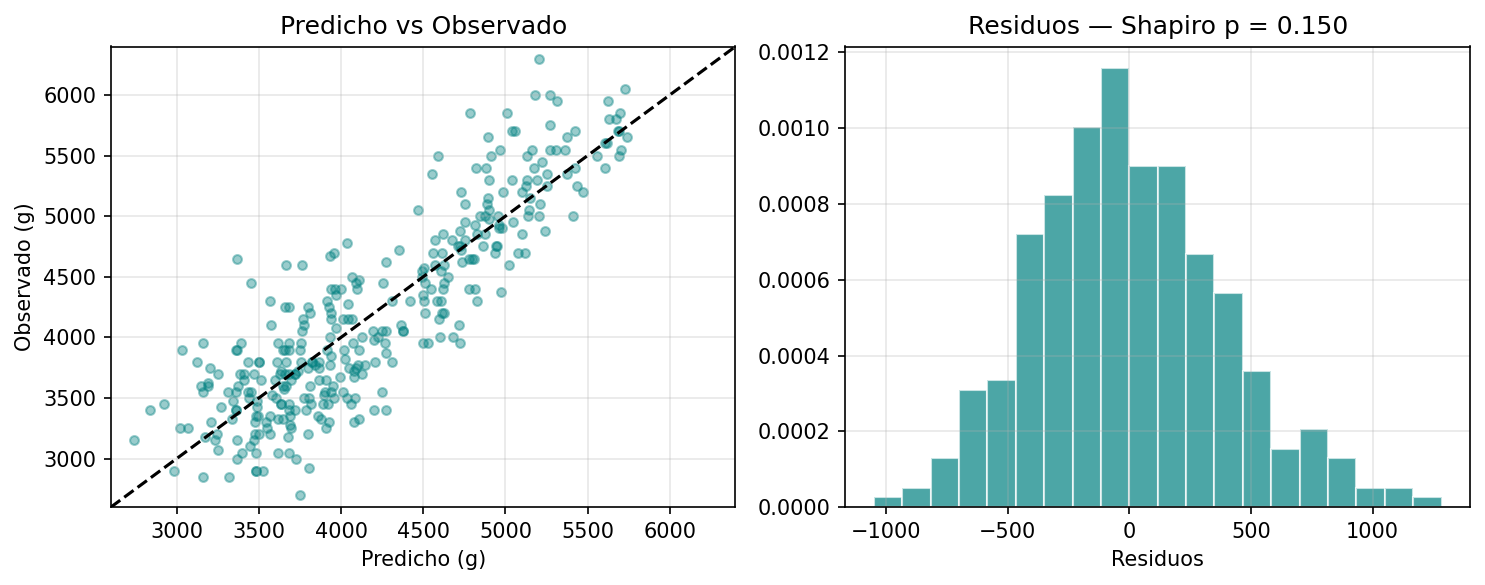

In [40]:
y_pred_m  = modelo_m.fittedvalues
resid_m   = modelo_m.resid
shapiro_m = stats.shapiro(resid_m)[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# Predicho vs Observado
lims = [y_arr.min() - 100, y_arr.max() + 100]
axes[0].scatter(y_pred_m, y_arr, alpha=0.4, color='teal', s=18)
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('Predicho (g)')
axes[0].set_ylabel('Observado (g)')
axes[0].set_title('Predicho vs Observado')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].grid(alpha=0.3)

# Distribucion residuos
axes[1].hist(resid_m, bins=20, color='teal', alpha=0.7, density=True, edgecolor='white')
axes[1].set_title(f'Residuos — Shapiro p = {shapiro_m:.3f}')
axes[1].set_xlabel('Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2g) Selección de Variables

> Use `SequentialFeatureSelector` con dirección `backward` para identificar el **subconjunto óptimo** de predictores.
> Compare el modelo reducido con el completo en términos de $R^2_{\text{adj}}$ y AIC.
> ¿Se justifica aplicar el principio de parsimonia?


In [41]:
reg = LinearRegression()
sfs = SequentialFeatureSelector(reg, direction='backward')
sfs.fit(df[predictors], y_arr)
selected = list(sfs.get_feature_names_out())
print(f'Variables seleccionadas (backward): {selected}')

# Modelo reducido
X_red = sm.add_constant(df[selected])
model_red = sm.OLS(y_arr, X_red.values).fit()

print()
print(f"{'Metrica':<15} {'Completo':>12} {'Reducido':>12}")
print(f"{'R2_adj':<15} {modelo_m.rsquared_adj:>12.4f} {model_red.rsquared_adj:>12.4f}")
print(f"{'AIC':<15} {modelo_m.aic:>12.2f} {model_red.aic:>12.2f}")
print(f"{'# predictores':<15} {m:>12} {len(selected):>12}")
print(model_red.summary())


Variables seleccionadas (backward): ['bill_depth_mm', 'flipper_length_mm']

Metrica             Completo     Reducido
R2_adj                0.7618       0.7622
AIC                  4927.55      4925.93
# predictores              3            2
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     533.2
Date:                Sat, 02 May 2026   Prob (F-statistic):          4.28e-104
Time:                        23:38:12   Log-Likelihood:                -2460.0
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     330   BIC:                             4937.
Df Model:                           2                                         
Covariance Type:            nonrobust        

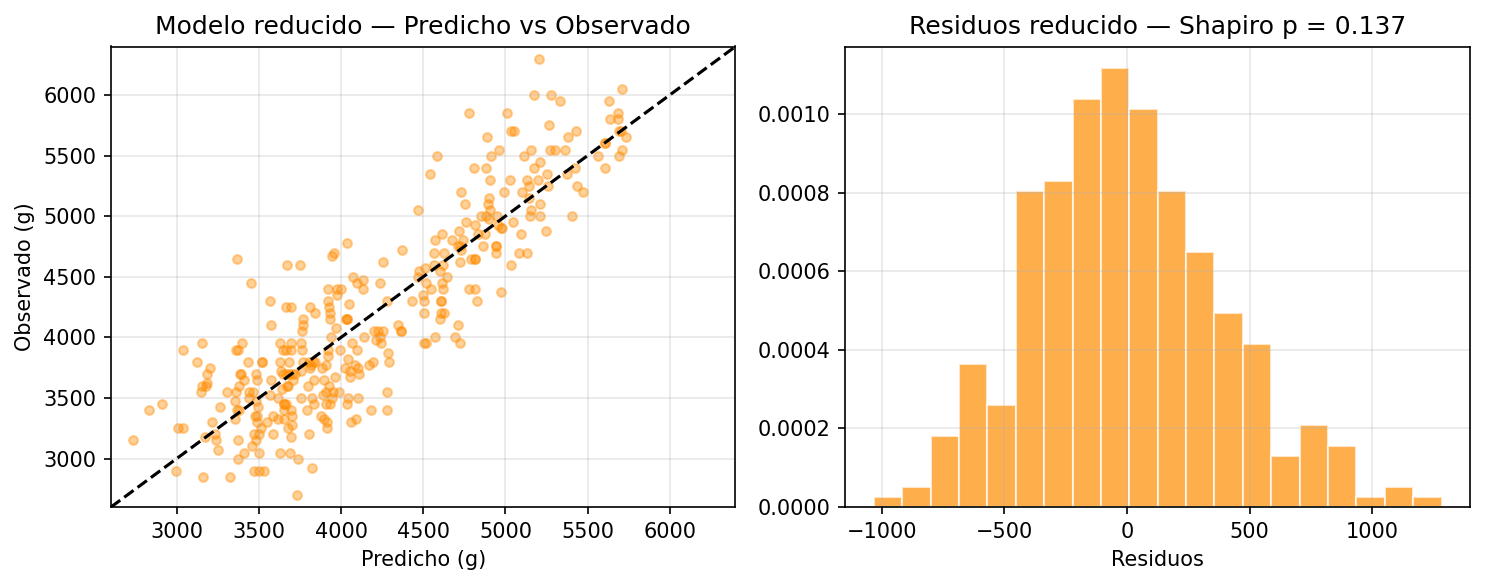

In [ ]:
# Grafico comparativo final: modelo reducido
y_pred_red  = model_red.fittedvalues
resid_red   = model_red.resid
shapiro_red = stats.shapiro(resid_red)[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

axes[0].scatter(y_pred_red, y_arr, alpha=0.4, color='darkorange', s=18)
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('Predicho (g)')
axes[0].set_ylabel('Observado (g)')
axes[0].set_title('Modelo reducido — Predicho vs Observado')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].grid(alpha=0.3)

axes[1].hist(resid_red, bins=20, color='darkorange', alpha=0.7, density=True, edgecolor='white')
axes[1].set_title(f'Residuos reducido — Shapiro p = {shapiro_red:.3f}')
axes[1].set_xlabel('Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
